# Gráficas del átomo de litio (electrón de valencia)

Este notebook:

1. Define la malla radial y constantes del modelo.
2. Calcula el potencial efectivo y el potencial coulombiano.
3. Resuelve la ecuación radial por diferencias finitas para estados `s` y `p`.
4. Normaliza funciones de onda y exporta archivos `.dat`.
5. Grafica:
   - Potencial efectivo vs coulombiano.
   - Panel A: `2s`, `3s`, `4s`; Panel B: `2p`, `3p`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# SciPy acelera la diagonalización tridiagonal; si no está, usamos NumPy.
try:
    from scipy.linalg import eigh_tridiagonal
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

# ------------------------------
# Constantes y malla radial
# ------------------------------
Z = 3.0
alpha = 2.535930  # parámetro del modelo del documento
r_min = 1.0e-4
r_max = 120.0
n_points = 2200

r = np.linspace(r_min, r_max, n_points)
dr = r[1] - r[0]

hartree_to_ev = 27.211386245988

In [2]:
# ------------------------------
# Potenciales
# ------------------------------
def v_eff_core(rr, z=Z, a=alpha):
    """Potencial efectivo del electrón de valencia (sin término centrífugo)."""
    return -z / rr + 2.0 / rr * (1.0 - (1.0 + a * rr) * np.exp(-2.0 * a * rr))


def v_coulomb_valence(rr, z=Z):
    """Potencial coulombiano de largo alcance para Li: -(Z-2)/r = -1/r."""
    return -(z - 2.0) / rr


Veff = v_eff_core(r)
Vc = v_coulomb_valence(r)

In [7]:
# ------------------------------
# Solución radial por diferencias finitas
# ------------------------------
def solve_states_for_l(l, n_keep=5):
    """
    Resuelve H u = E u para un l fijo, con u(0)=u(r_max)=0.
    Devuelve energías (Ha), u(r), y R(r)=u(r)/r para los primeros estados ligados.
    """
    V_l = v_eff_core(r) + l * (l + 1.0) / (2.0 * r**2)

    # Malla interior (condición de frontera de Dirichlet en extremos)
    r_in = r[1:-1]
    V_in = V_l[1:-1]
    n = r_in.size

    main = 1.0 / dr**2 + V_in
    off = -0.5 / dr**2 * np.ones(n - 1)

    if HAVE_SCIPY:
        evals, evecs = eigh_tridiagonal(main, off, select="i", select_range=(0, min(220, n - 1)))
    else:
        # Fallback denso (más lento)
        H = np.diag(main) + np.diag(off, k=1) + np.diag(off, k=-1)
        evals, evecs = np.linalg.eigh(H)

    bound_mask = evals < 0.0
    evals = evals[bound_mask][:n_keep]
    evecs = evecs[:, bound_mask][:, :n_keep]

    # Reconstrucción y normalización de u en malla completa
    u_list = []
    R_list = []

    for j in range(evecs.shape[1]):
        u = np.zeros_like(r)
        u[1:-1] = evecs[:, j]

        # Normalización continua: ∫|u|^2 dr = 1
        norm_u = np.sqrt(np.trapezoid(u**2, r))
        if norm_u > 0:
            u /= norm_u

        R = np.zeros_like(r)
        R[1:] = u[1:] / r[1:]

        # Fijar fase para que el primer máximo relevante sea positivo
        idx_ref = np.argmax(np.abs(R[1:200])) + 1
        if R[idx_ref] < 0:
            u *= -1
            R *= -1

        u_list.append(u)
        R_list.append(R)

    return evals, np.array(u_list), np.array(R_list)


# Estados solicitados
# Para l=0, el primer estado ligado es muy profundo (tipo 1s del modelo).
# Se omite para reportar 2s, 3s, 4s.
E_s_all, U_s_all, R_s_all = solve_states_for_l(l=0, n_keep=4)
E_s = E_s_all[1:4]
U_s = U_s_all[1:4]
R_s = R_s_all[1:4]

# Para l=1 se toman los dos primeros ligados: 2p, 3p.
E_p, U_p, R_p = solve_states_for_l(l=1, n_keep=2)

print("Energías s (eV):", E_s * hartree_to_ev)
print("Energías p (eV):", E_p * hartree_to_ev)

Energías s (eV): [-4.81977894 -1.88805013 -1.00156199]
Energías p (eV): [-3.4323694  -1.52240881]


In [8]:
# ------------------------------
# Exportar .dat
# ------------------------------
potential_dat = np.column_stack([r, Vc, Veff])
np.savetxt(
    "potential_litio.dat",
    potential_dat,
    header="r(a.u.)  Vcoulomb(a.u.)  Veff(a.u.)",
)

wave_dat = np.column_stack([
    r,
    R_s[0], R_s[1], R_s[2],
    R_p[0], R_p[1],
])
np.savetxt(
    "funciones_radiales_litio.dat",
    wave_dat,
    header="r(a.u.)  R_2s  R_3s  R_4s  R_2p  R_3p",
)

print("Archivos generados:")
print("- potential_litio.dat")
print("- funciones_radiales_litio.dat")

Archivos generados:
- potential_litio.dat
- funciones_radiales_litio.dat


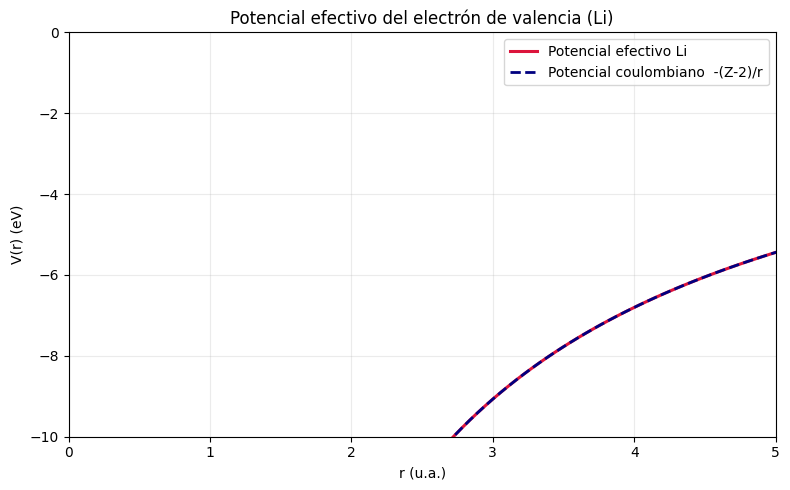

In [12]:
# ------------------------------
# Gráfica 1: potencial efectivo vs coulombiano (escala libro)
# ------------------------------
Veff_ev = Veff * hartree_to_ev
Vc_ev = Vc * hartree_to_ev

# Opcional: evitar la singularidad visual en r muy pequeño
mask = r >= 0.02

plt.figure(figsize=(8, 5))
plt.plot(r[mask], Veff_ev[mask], lw=2.2, color="crimson", label="Potencial efectivo Li")
plt.plot(r[mask], Vc_ev[mask], lw=2.0, ls="--", color="navy", label="Potencial coulombiano  -(Z-2)/r")

plt.xlim(0.0, 5.0)
plt.ylim(-10.0, 0.0)
plt.xlabel("r (u.a.)")
plt.ylabel("V(r) (eV)")
plt.title("Potencial efectivo del electrón de valencia (Li)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

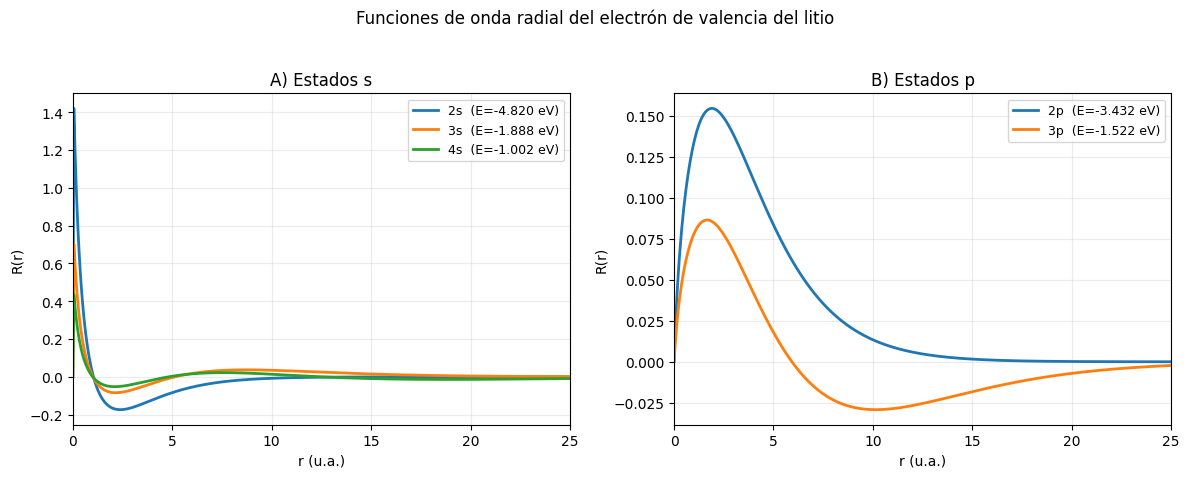

In [11]:
# ------------------------------
# Gráfica 2: funciones de onda radial
# Panel A: 2s, 3s, 4s  |  Panel B: 2p, 3p
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)

# Panel A (s)
axes[0].plot(r, R_s[0], label=f"2s  (E={E_s[0]*hartree_to_ev:.3f} eV)", lw=2.0)
axes[0].plot(r, R_s[1], label=f"3s  (E={E_s[1]*hartree_to_ev:.3f} eV)", lw=2.0)
axes[0].plot(r, R_s[2], label=f"4s  (E={E_s[2]*hartree_to_ev:.3f} eV)", lw=2.0)
axes[0].set_xlim(0.0, 25.0)
axes[0].set_xlabel("r (u.a.)")
axes[0].set_ylabel("R(r)")
axes[0].set_title("A) Estados s")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)

# Panel B (p)
axes[1].plot(r, R_p[0], label=f"2p  (E={E_p[0]*hartree_to_ev:.3f} eV)", lw=2.0)
axes[1].plot(r, R_p[1], label=f"3p  (E={E_p[1]*hartree_to_ev:.3f} eV)", lw=2.0)
axes[1].set_xlim(0.0, 25.0)
axes[1].set_xlabel("r (u.a.)")
axes[1].set_ylabel("R(r)")
axes[1].set_title("B) Estados p")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

plt.suptitle("Funciones de onda radial del electrón de valencia del litio", y=1.03)
plt.tight_layout()
plt.show()